In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import riskfolio as rp
import numpy as np
import pandas as pd
from pathlib import Path

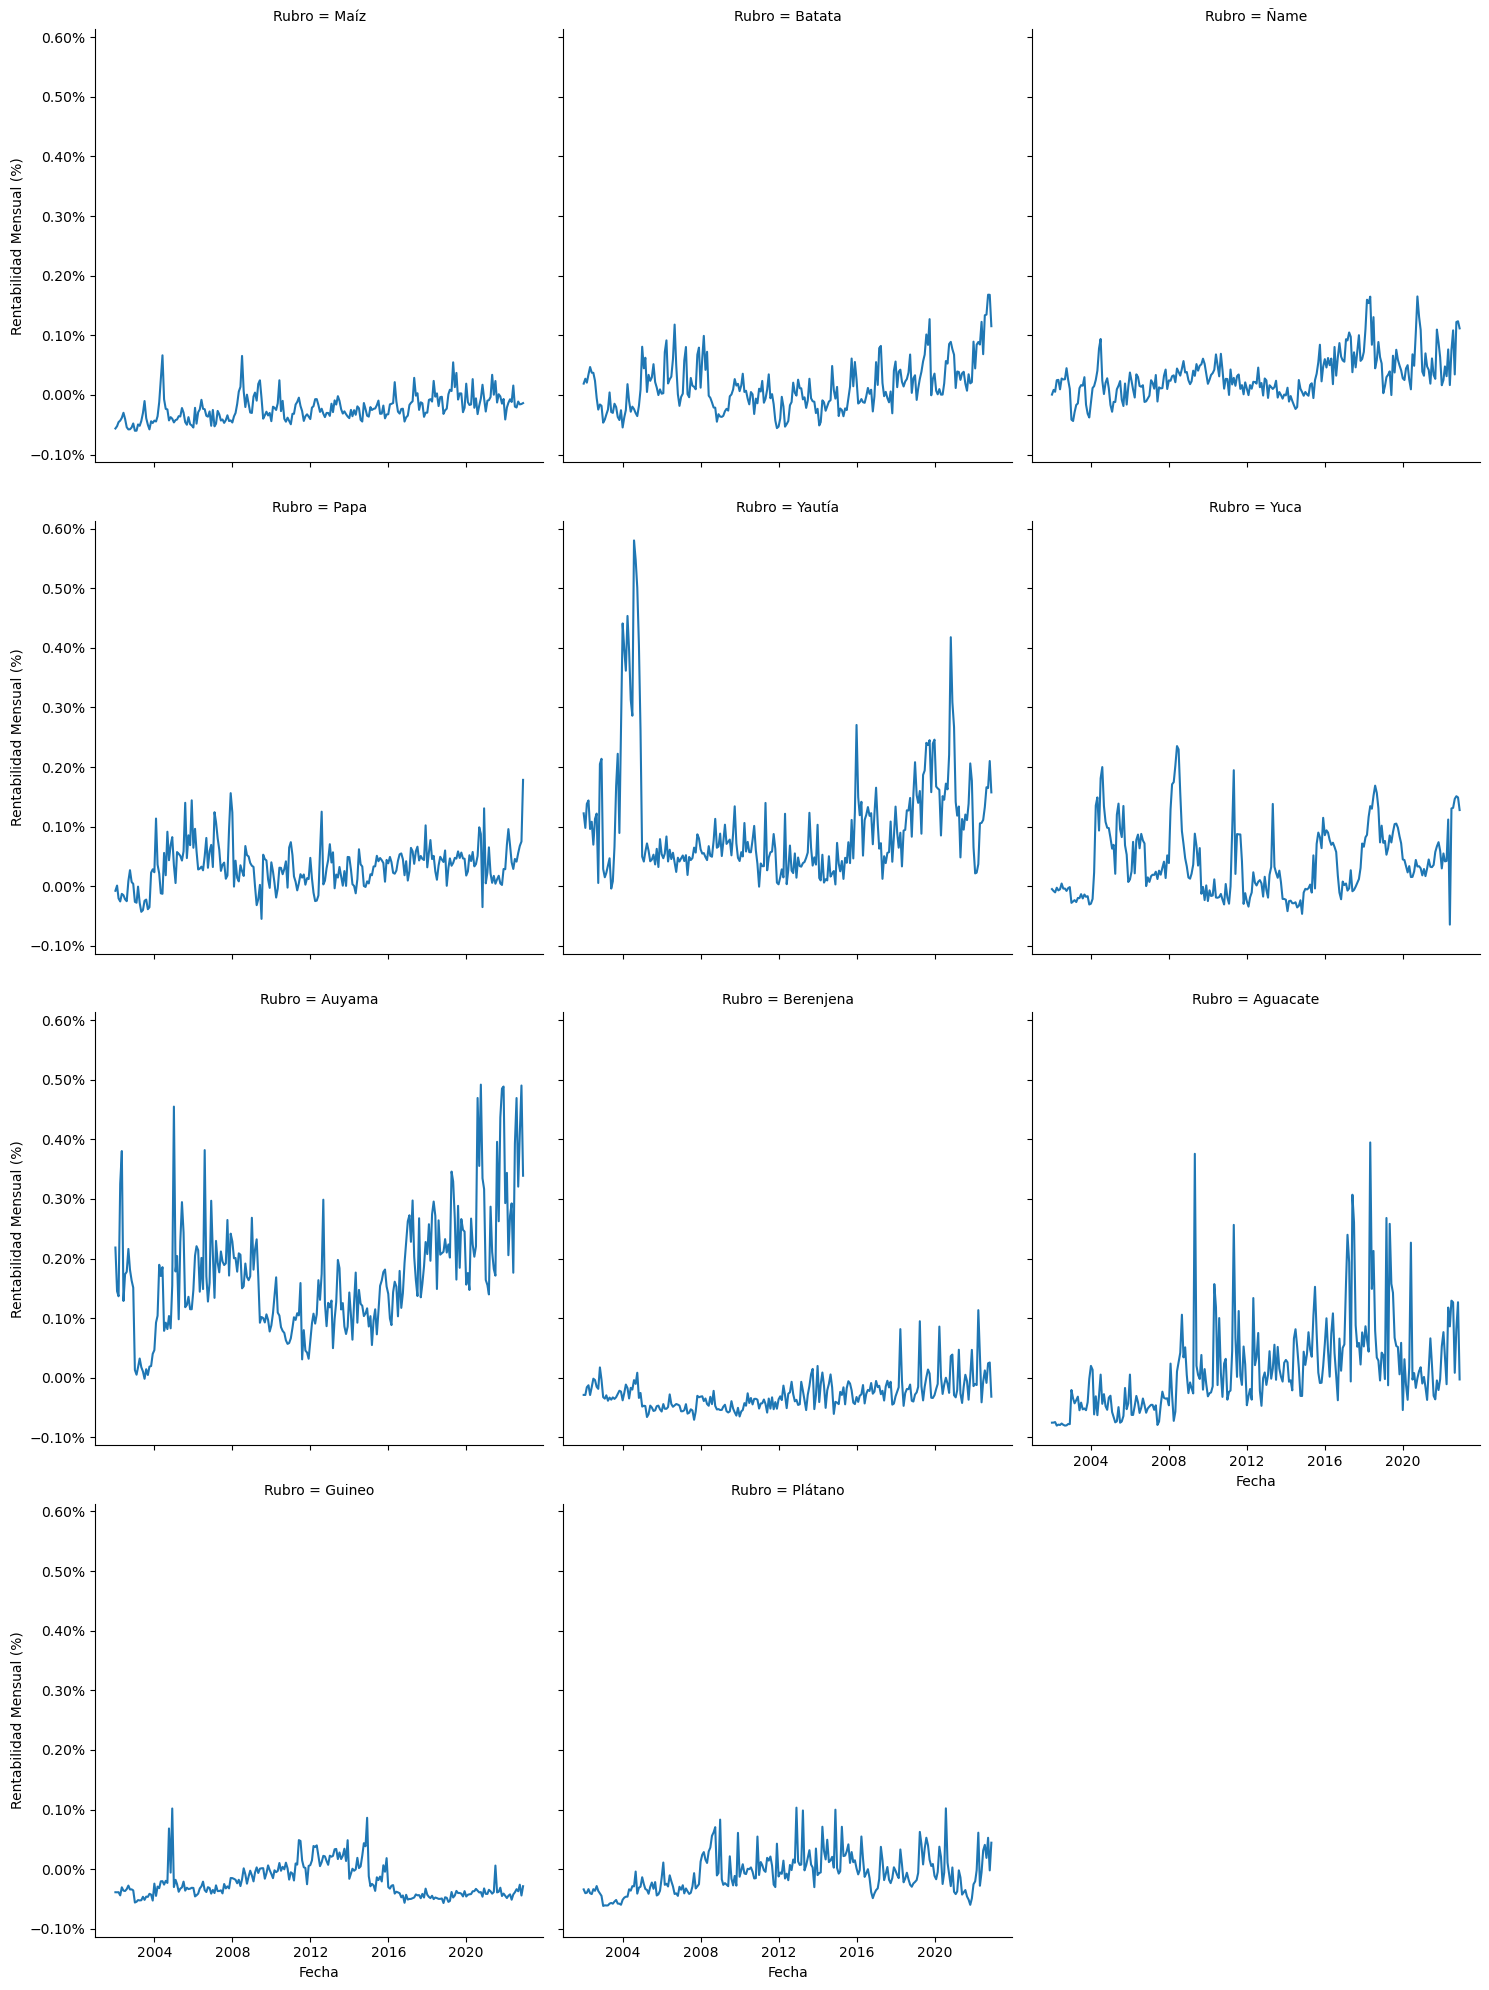

In [44]:
df = pd.read_excel(Path().cwd().parent / "data" / "dataset.xlsx")
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df[
    (df['Fecha'] >= '2002-01-01') & 
    (~df['Rubro'].isin(['Arroz']))
]
# Crear el gráfico
g = sns.relplot(
    data=df,
    x="Fecha",
    y="Rentabilidad Mensual (%)",
    col="Rubro",
    kind="line",
    col_wrap=3,
)

# Aplicar el formateador de porcentaje a cada subgráfico
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter())

# Ajustar el diseño
plt.tight_layout()

In [45]:
Y =  df.pivot_table(
    index='Fecha',
    columns='Rubro',
    values='Rentabilidad Mensual (%)'
)

display(Y.head())

Rubro,Aguacate,Auyama,Batata,Berenjena,Guineo,Maíz,Papa,Plátano,Yautía,Yuca,Ñame
Fecha,,,,,,,,,,,
2002-01-01,-0.075320,0.218419,0.018980,-0.028753,-0.038660,-0.056303,-0.007424,-0.033895,0.122457,-0.004600,0.000572
2002-02-01,-0.075190,0.145110,0.027172,-0.028831,-0.038772,-0.052425,0.001293,-0.040238,0.098006,-0.007843,0.008443
2002-03-01,-0.074313,0.136720,0.020576,-0.015888,-0.038607,-0.045640,-0.020207,-0.039528,0.138401,-0.010075,0.005265
2002-04-01,-0.080262,0.325492,0.034402,-0.012572,-0.043942,-0.043040,-0.025324,-0.033433,0.144081,-0.002280,0.024663
2002-05-01,-0.078558,0.380262,0.046819,-0.028974,-0.030402,-0.038448,-0.012607,-0.040308,0.096204,-0.006791,0.025283


In [46]:
# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu = "hist"  # Method to estimate expected returns based on historical data.
method_cov = "hist"  # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model = "Classic"  # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = "MV"  # Risk measure used, this time will be variance
obj = "Sharpe"  # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True  # Use historical scenarios for risk measures that depend on scenarios
rf = 0  # Risk free rate
l = 0  # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)


,Aguacate,Auyama,Batata,Berenjena,Guineo,Maíz,Papa,Plátano,Yautía,Yuca,Ñame
weights,0.004872,0.415279,4.018437e-09,2.799923e-09,3.029405e-08,4.195832e-09,0.359269,1.119294e-08,0.22058,1.057185e-08,2.653917e-08


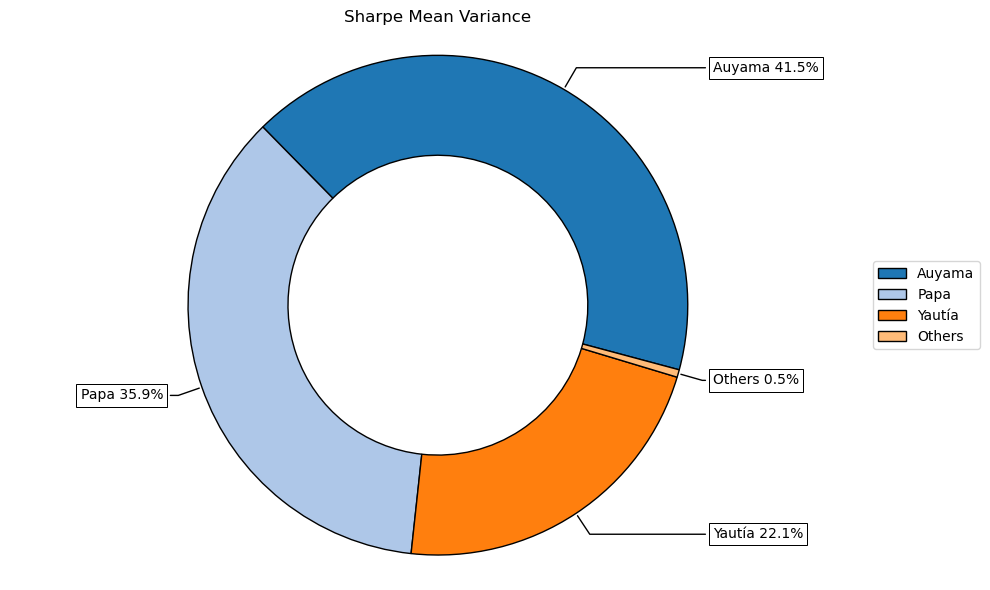

In [47]:
ax = rp.plot_pie(
    w=w,
    title="Sharpe Mean Variance",
    others=0.05,
    nrow=25,
    cmap="tab20",
    height=6,
    width=10,
    ax=None,
)


In [48]:
points = 50  # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())


,Aguacate,Auyama,Batata,Berenjena,Guineo,Maíz,Papa,Plátano,Yautía,Yuca,Ñame
0,4.022661e-10,3.278584e-10,5.635940e-02,2.013330e-01,0.304344,0.301299,0.136665,8.052848e-10,1.398304e-08,8.681439e-10,3.474008e-09
1,5.237417e-09,2.759211e-02,4.338266e-02,7.747026e-02,0.345660,0.200908,0.190397,7.075222e-09,3.248805e-02,8.215576e-09,8.210206e-02
2,1.596813e-09,5.337743e-02,2.307036e-02,1.942115e-02,0.375415,0.156453,0.211769,1.260577e-09,4.642296e-02,6.741226e-10,1.140702e-01
3,1.353149e-03,7.708847e-02,1.955793e-07,2.124505e-09,0.396551,0.097338,0.230561,5.667089e-09,5.757130e-02,3.579862e-09,1.395365e-01
4,1.051188e-02,9.572623e-02,9.463299e-09,5.838127e-09,0.413375,0.015807,0.241239,2.624614e-08,6.844305e-02,6.244200e-08,1.548980e-01


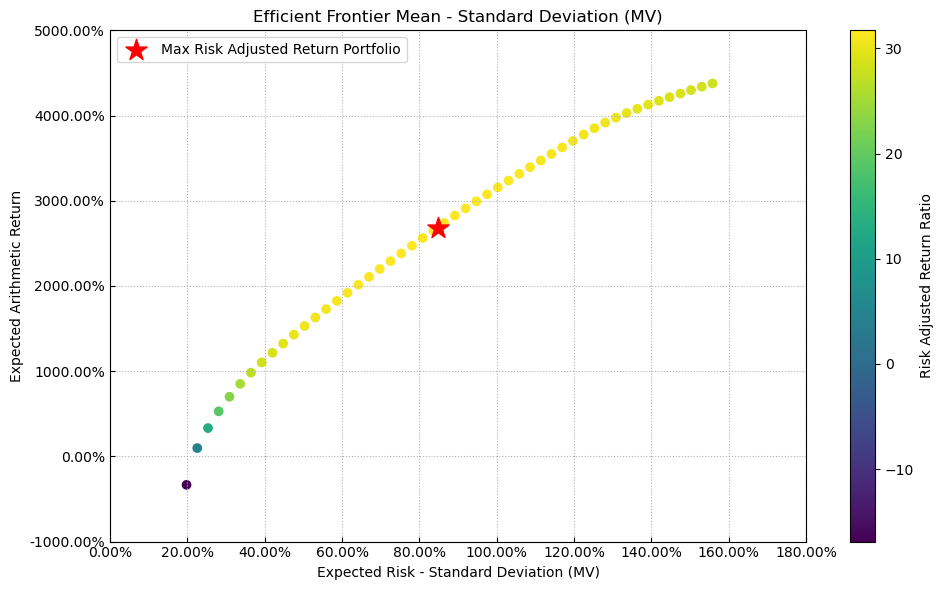

In [49]:
label = "Max Risk Adjusted Return Portfolio"  # Title of point
mu = port.mu  # Expected returns
cov = port.cov  # Covariance matrix
returns = port.returns  # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    alpha=0.05,
    cmap="viridis",
    w=w,
    label=label,
    marker="*",
    s=16,
    c="r",
    height=6,
    width=10,
    ax=None,
)


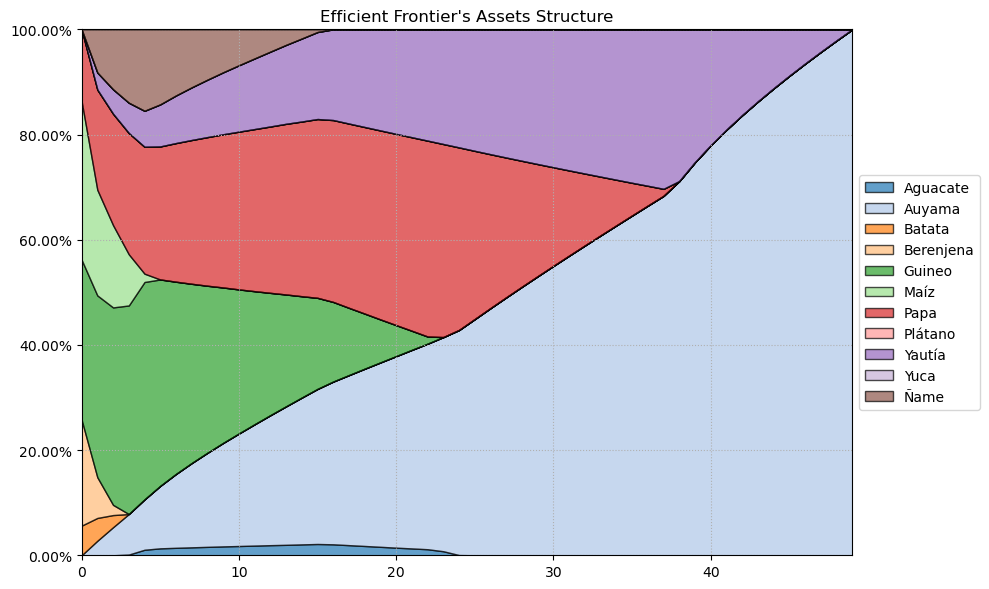

In [50]:
ax = rp.plot_frontier_area(
    w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None
)


<Axes: title={'center': 'Portfolio Returns Histogram'}, ylabel='Probability Density'>

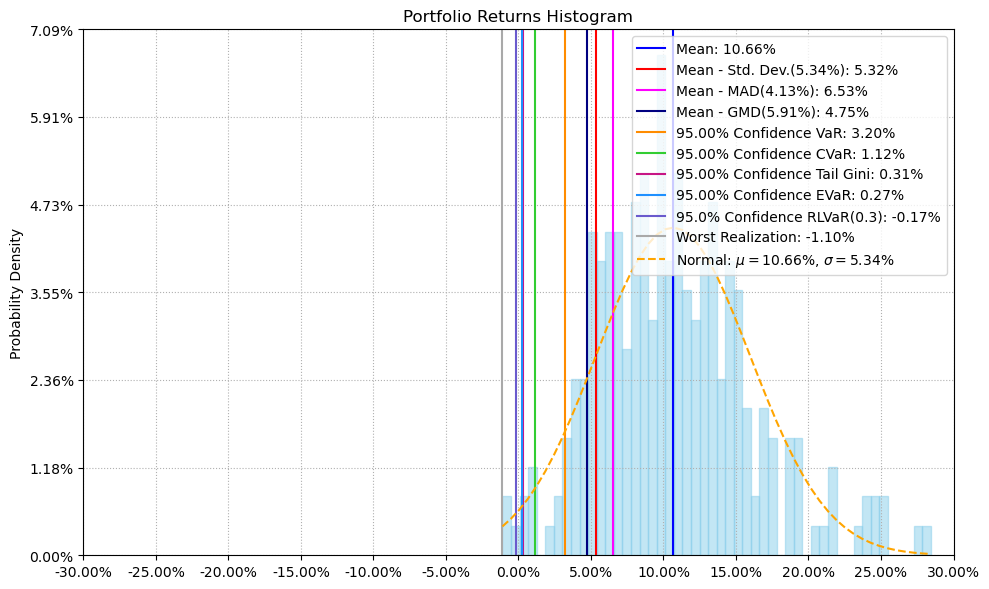

In [51]:
rp.plot_hist(returns=Y, w=w, alpha=0.05, bins=50, height=6, width=10, ax=None)


/home/ian/miniforge3/envs/intec/lib/python3.12/site-packages/riskfolio/src/PlotFunctions.py:2996: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


<Axes: >

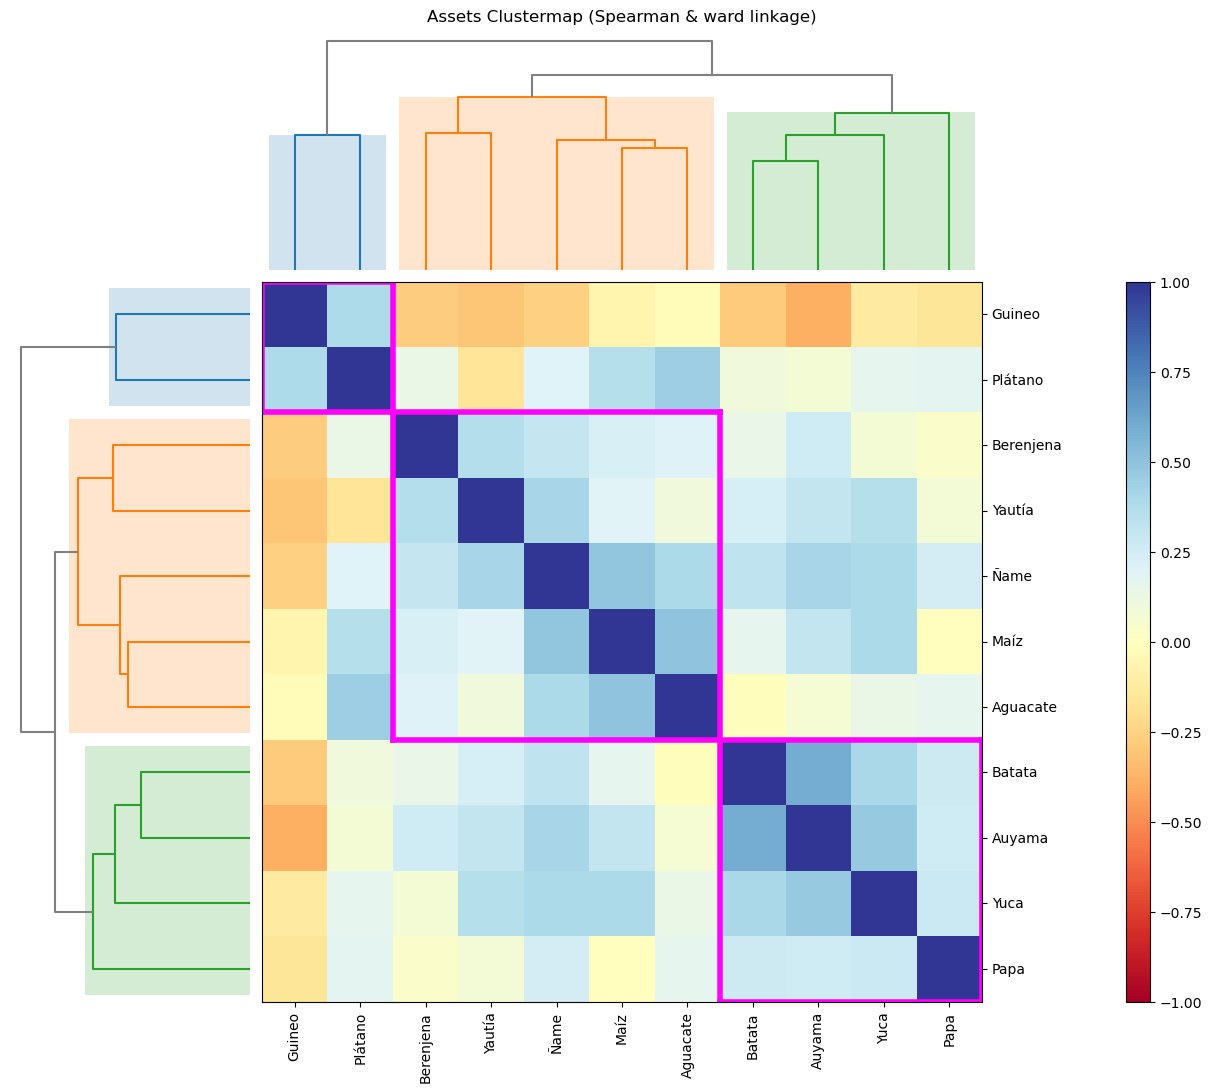

In [52]:
rp.plot_clusters(
    returns=Y,
    codependence="spearman",
    linkage="ward",
    k=None,
    max_k=10,
    leaf_order=True,
    dendrogram=True,
    ax=None,
)


In [53]:
# rp.plot_series(returns=Y, w=frontier, cmap="tab20", height=6, width=10, ax=None)


In [54]:
w.plot_


AttributeError: 'DataFrame' object has no attribute 'plot_'

In [34]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = [
    "MV",
    "MAD",
    "MSV",
    "FLPM",
    "SLPM",
    "CVaR",
    "EVaR",
    "WR",
    "MDD",
    "ADD",
    "CDaR",
    "UCI",
    "EDaR",
]

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model, rm=i, obj=obj, rf=r, 'Plátano'f, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)

w_s.columns = rms
, 'Plátano'

In [ ]:
w_s.style.format("{:.2%}").background_gradient(cmap="YlGn")


,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
Aguacate,8.96%,4.22%,4.82%,4.14%,2.16%,8.40%,9.27%,0.03%,7.50%,3.19%,6.90%,8.90%,0.93%
Auyama,29.59%,37.71%,42.62%,75.90%,73.82%,40.55%,43.68%,34.17%,44.57%,68.46%,55.30%,20.90%,91.27%
Batata,0.00%,0.00%,0.00%,1.36%,2.62%,0.00%,0.00%,0.00%,1.39%,1.92%,1.41%,2.75%,1.33%
Berenjena,0.00%,0.00%,0.00%,2.48%,2.92%,0.00%,0.00%,0.00%,2.13%,3.63%,2.13%,2.15%,0.31%
Maíz,0.00%,0.00%,0.00%,1.80%,2.98%,0.00%,0.00%,0.00%,1.90%,2.64%,1.73%,3.51%,0.83%
Papa,42.60%,45.51%,37.73%,4.39%,2.63%,24.31%,23.04%,42.92%,15.50%,5.31%,9.42%,28.65%,1.16%
Yautía,18.86%,12.55%,14.83%,0.65%,8.71%,26.73%,10.46%,0.50%,16.14%,4.35%,13.11%,17.54%,1.78%
Yuca,0.00%,0.00%,0.00%,4.20%,1.95%,0.00%,0.00%,0.00%,3.74%,4.80%,3.89%,4.19%,1.26%
Ñame,0.00%,0.00%,0.00%,5.09%,2.22%,0.00%,13.56%,22.38%,7.11%,5.70%,6.11%,11.42%,1.11%


<Axes: >

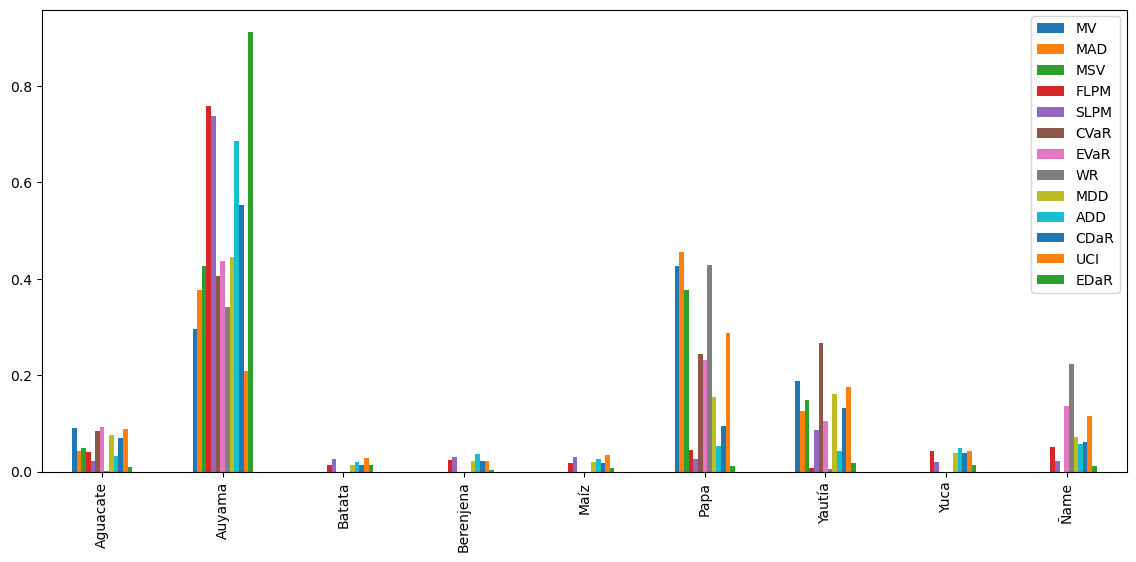

In [55]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(14)
fig.set_figheight(6)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot.bar(ax=ax)
